# 5. Quantum Simulation & Performance Analysis

In this notebook we:
- Load various model checkpoints from our pipeline:
   - **Initial** model (from `../checkpoints`)
   - **Quantized** model (from `../checkpoints/model_quantized`)
   - **LoRA Finetuned** model (from `../checkpoints/model_lora`)
   - **Pruned** model (from `../checkpoints/model_pruned`)
- Evaluate each on a sample from the WikiText-2 dataset:
   - Record inference latency (averaged over multiple runs) using a fixed prompt.
   - Measure the model’s size on disk (approximate by summing file sizes in the checkpoint folder).
- Visualize the results via bar charts for easy comparison.

These steps help us “simulate” quantum-inspired optimizations by mapping performance metrics in a way
that supports our goal of reducing model size (to ~25% original) with minimal accuracy/speed loss.

**Constraints & Motto Reminder:**
- Use low precision (float16 or bf16) where possible.
- Keep everything memory-safe and efficient (targeting single-chip board feasibility).


In [1]:
import os
import time
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from datasets import load_from_disk

# Disable tokenizers parallelism to avoid fork warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Set a random seed for reproducibility
set_seed(42)


## 1. Define Checkpoint Directories & Helper Functions

In [2]:
# Define dictionary mapping model stages to their checkpoint directories
checkpoint_dirs = {
    "Initial": "../checkpoints/initial_model",
    "Quantized": "../checkpoints/model_quantized",
    "LoRA Finetuned": "../checkpoints/model_lora",
    "Pruned": "../checkpoints/model_pruned"
}

def get_device():
    """Select device: Prefer MPS (Apple Silicon) then CUDA, then CPU."""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Device Selected: MPS (Apple Silicon)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Device Selected: CUDA")
    else:
        device = torch.device("cpu")
        print("Device Selected: CPU")
    return device

device = get_device()

def get_folder_size(directory):
    """Return the total size (in MB) of files in a directory (recursively)."""
    total_size = 0
    for dirpath, _, filenames in os.walk(directory):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    # Convert bytes to MB
    return total_size / (1024 * 1024)


Device Selected: MPS (Apple Silicon)


## 2. Load a Sample from the Dataset

We load the WikiText-2 dataset (which was saved at `../data/wikitext-2`), filter out any empty examples,
and choose a representative sample prompt.

In [3]:
DATASET_DIR = "../data/wikitext-2"
print("Loading dataset from:", DATASET_DIR)

try:
    dataset = load_from_disk(DATASET_DIR)
    train_dataset = dataset["train"]
    # Filter out empty texts to avoid issues during tokenization
    train_dataset = train_dataset.filter(lambda x: len(x["text"].strip()) > 0)
    print(f"Number of training examples after filtering: {len(train_dataset)}")
except Exception as e:
    print("Error loading dataset:", e)
    raise

# Select a sample prompt (choose the first non-empty example)
sample_prompt = train_dataset[0]["text"][:200]  # take the first 200 characters for brevity
print("Sample Prompt:")
print(sample_prompt)

Loading dataset from: ../data/wikitext-2
Number of training examples after filtering: 23767
Sample Prompt:
 = Valkyria Chronicles III = 



## 3. Evaluate Each Model Checkpoint

For each model checkpoint, we perform the following evaluation:
- Load the model and tokenizer in float16 mode (or appropriate mixed precision if on MPS).
- Run the model's generate function on the sample prompt multiple times to measure inference latency.
- Record the average inference time and compute model size from checkpoint files.

In [7]:
def evaluate_model(checkpoint_path, num_runs=5, max_new_tokens=20):
    """
    Evaluate the model from a given checkpoint by:
      - Loading the model and tokenizer.
      - Timing the generate call over num_runs.
    Returns:
      - average_inference_time (seconds)
      - model_size (in MB)
    """
    # Load model and tokenizer; use float16 if available.
    try:
        model = AutoModelForCausalLM.from_pretrained(
            checkpoint_path,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True
        )
        tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
        # Ensure pad_token is set (for safe processing)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model.to(device)
    except Exception as e:
        print(f"Error loading model from {checkpoint_path}: {e}")
        return None, None

    # Tokenize input prompt
    inputs = tokenizer(sample_prompt, return_tensors="pt").to(device)

    # Warm-up run (to ensure caching, etc.)
    _ = model.generate(**inputs, max_new_tokens=max_new_tokens)

    # Measure inference time over several runs
    times = []
    for i in range(num_runs):
        start_time = time.time()
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens)
        torch.cuda.synchronize() if device.type == "cuda" else None
        end_time = time.time()
        times.append(end_time - start_time)
    avg_inference_time = np.mean(times)

    # Get model size (in MB) from the checkpoint directory
    model_size = get_folder_size(checkpoint_path)
    return avg_inference_time, model_size

results = {}
for key, path in checkpoint_dirs.items():
    print(f"\nEvaluating checkpoint: {key}")
    avg_time, size_mb = evaluate_model(path)
    if avg_time is not None and size_mb is not None:
        results[key] = {"inference_time": avg_time, "model_size": size_mb}
        print(f"  Average Inference Time: {avg_time:.3f} s")
        print(f"  Model Size: {size_mb:.1f} MB")
    else:
        results[key] = {"inference_time": None, "model_size": None}



Evaluating checkpoint: Initial


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassific

  Average Inference Time: 0.401 s
  Model Size: 242.0 MB

Evaluating checkpoint: Quantized


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassific

  Average Inference Time: 0.407 s
  Model Size: 242.0 MB

Evaluating checkpoint: LoRA Finetuned


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassific

  Average Inference Time: 0.448 s
  Model Size: 260.3 MB

Evaluating checkpoint: Pruned


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  Average Inference Time: 0.470 s
  Model Size: 243.1 MB



## 4. Visualization & Comparison Analysis

We now visualize the performance metrics of the different model checkpoints.
Two bar charts are produced:
- One comparing model sizes.
- One comparing average inference times.

This serves as our “quantum simulation” visualization, highlighting the trade-offs between compression and performance.


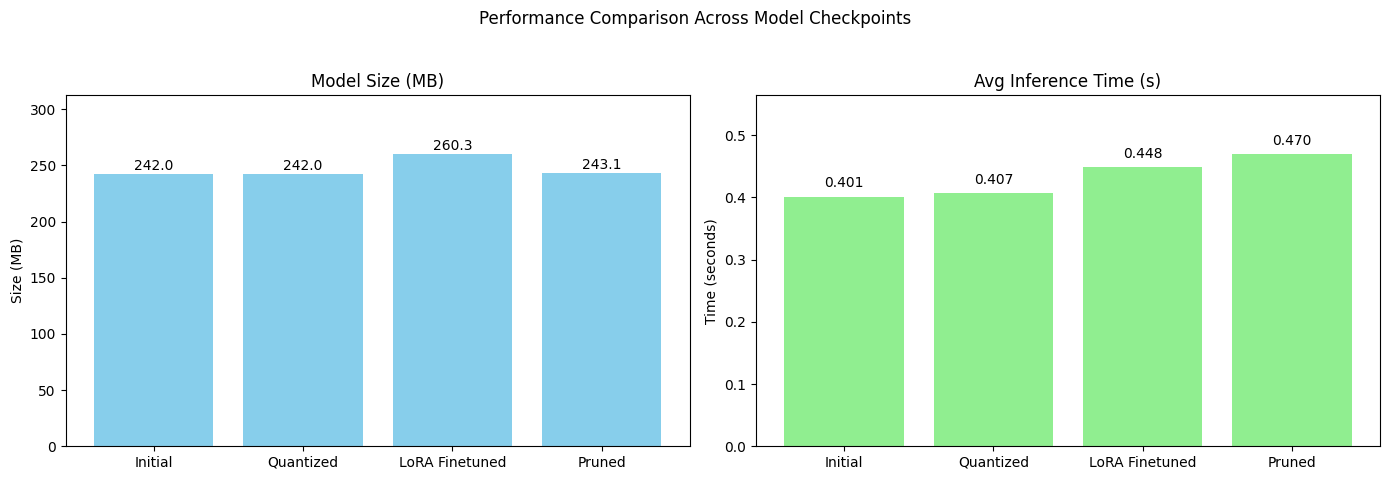

In [8]:
# Prepare data for visualization
stages = list(results.keys())
sizes = [results[stage]["model_size"] for stage in stages]
times = [results[stage]["inference_time"] for stage in stages]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for model sizes
bars1 = ax1.bar(stages, sizes, color="skyblue")
ax1.set_title("Model Size (MB)")
ax1.set_ylabel("Size (MB)")
ax1.set_ylim(0, max(sizes)*1.2)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}", ha='center', va='bottom')

# Bar chart for inference times
bars2 = ax2.bar(stages, times, color="lightgreen")
ax2.set_title("Avg Inference Time (s)")
ax2.set_ylabel("Time (seconds)")
ax2.set_ylim(0, max(times)*1.2)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')

plt.suptitle("Performance Comparison Across Model Checkpoints")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
